# 1. 환경설정

In [1]:
!pip install koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 108.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
visit = pd.read_csv(r'/content/drive/MyDrive/코드잇_데이터분석_6기/중급 프로젝트2/02. 중급 2/trial_visit_info.csv')
register = pd.read_csv(r'/content/drive/MyDrive/코드잇_데이터분석_6기/중급 프로젝트2/02. 중급 2/trial_register.csv')
payment = pd.read_csv(r'/content/drive/MyDrive/코드잇_데이터분석_6기/중급 프로젝트2/02. 중급 2/trial_payment.csv')

In [4]:
# trial_date 기준으로 오름차순 정렬한 후, user_uuid 기준으로 중복 제거
register = register.sort_values('trial_date').drop_duplicates(subset='user_uuid', keep='first')
visit = visit.dropna()

In [5]:
visit.columns

Index(['site_id', 'date', 'stay_time', 'stay_time_second', 'first_enter_time',
       'last_leave_time', 'user_uuid'],
      dtype='object')

# 모델링

## 모델링 목표

- 목표: 체험 신청 이후 실제로 결제까지 이어지게 만드는 유저 행동 패턴 파악 예측 모델 만들기
- 중점 분석대상
    - 신청 일시, 입실 시간, 체류 시간
    - 방문 횟수
    - 체험 후 행동 (예: 재방문 여부 등)

## 주요 피처 엔지니어링

In [6]:
visit.columns

Index(['site_id', 'date', 'stay_time', 'stay_time_second', 'first_enter_time',
       'last_leave_time', 'user_uuid'],
      dtype='object')

In [7]:
register.columns

Index(['trial_date', 'user_uuid'], dtype='object')

In [8]:
payment.columns

Index(['is_payment', 'user_uuid'], dtype='object')

In [9]:
# user_uuid 기준으로 3개 테이블 병합
df = register.merge(visit, on='user_uuid', how='left').merge(payment, on='user_uuid', how='left')

In [10]:
# 마이크로초(소수점 이하) 제거
df['first_enter_time'] = df['first_enter_time'].str.split('.').str[0]
df['last_leave_time'] = df['last_leave_time'].str.split('.').str[0]

In [11]:
# 날짜 처리: datetime 형 변환
df['trial_date'] = pd.to_datetime(df['trial_date'])
df['date'] = pd.to_datetime(df['date'])
df['first_enter_time'] = pd.to_datetime(df['first_enter_time'])
df['last_leave_time'] = pd.to_datetime(df['last_leave_time'])

In [12]:
df.head()

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,trial_date,user_uuid,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,is_payment
0,2021-05-01,f25078d1-1030-485c-85c5-dc82d6987043,NaN,NaT,NaN,NaN,NaT,NaT,1
1,2021-05-01,9f5e2bd3-65c9-4800-84c1-f5c93f44d096,NaN,NaT,NaN,NaN,NaT,NaT,1
2,2021-05-01,844319ff-cd15-4633-9900-6eaf4dc68b68,NaN,NaT,NaN,NaN,NaT,NaT,1
3,2021-05-01,badbde4d-886b-4992-a8e3-fd0c05640183,NaN,NaT,NaN,NaN,NaT,NaT,1
4,2021-05-01,fce967b5-070c-46ed-a5fa-ef7d298cc7aa,NaN,NaT,NaN,NaN,NaT,NaT,1


In [13]:
is_paid = (df['is_payment'] == 1).sum()
is_paid

np.int64(5858)

In [14]:
# 방문 기록이 없는데 결제한 사람 수
no_visit_but_paid = df[(df['stay_time_second'].isna()) & (df['is_payment'] == 1)]
print(len(no_visit_but_paid))

1256


In [15]:
# 방문 기록 없는 유저 제거
df = df[df['stay_time_second'].notna()]

- 본 모델은 체험 기간 중 방문 행동을 바탕으로 전환 가능성을 예측하기 위해 설계되었습니다.
- 이에 따라, 행동 기록이 존재하지 않는 사용자(예: 방문 없이 결제 or 미결제)는
- 본 모델의 예측 로직에 적합하지 않아 학습 대상에서 제외하였습니다.
- 단, 방문 없이 결제한 사용자는 전환 성과 측면에서는 의미 있는 그룹이므로
- 별도 채널 분석을 통해 관리할 수 있습니다.

In [16]:
# 체류시간 이상치 확인
df.sort_values(by='stay_time', ascending=False).head()

,trial_date,user_uuid,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,is_payment
5208,2022-03-24,699c70ca-64ea-461e-bdd8-66b7c314c582,5.0,2022-03-25,23:59:37.348440,86377.0,2022-03-25,2022-03-25 23:59:59,0
7020,2022-08-08,5c6938dc-043e-4861-943e-01bd1f068826,2.0,2022-08-10,23:59:36.181159,86376.0,2022-08-10,2022-08-10 23:59:59,1
13608,2023-11-17,3304dead-5352-4f10-be40-036325a3b9f8,3.0,2023-11-18,23:58:45.766011,86325.0,2023-11-18,2023-11-18 23:59:59,0
5108,2022-03-19,4acf941b-b706-4891-a592-7e04784a1cc4,4.0,2022-03-21,23:58:42.775223,86322.0,2022-03-21,2022-03-21 23:59:59,0
11332,2023-06-19,58fb08df-2803-437b-b2c7-29b1e03a119b,1.0,2023-06-20,23:57:38.418795,86258.0,2023-06-20,2023-06-20 23:59:59,0


In [17]:
# 하루종일 머물렀다? 문제 유저 데이터 확인
df[df['user_uuid'] == '699c70ca-64ea-461e-bdd8-66b7c314c582']

,trial_date,user_uuid,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,is_payment
5207,2022-03-24,699c70ca-64ea-461e-bdd8-66b7c314c582,5.0,2022-03-27,13:29:00,48540.0,2022-03-27,2022-03-27 13:29:00,0
5208,2022-03-24,699c70ca-64ea-461e-bdd8-66b7c314c582,5.0,2022-03-25,23:59:37.348440,86377.0,2022-03-25,2022-03-25 23:59:59,0


In [18]:
# 문제 유저 입실 시간 확인
df.loc[df['user_uuid'] == '699c70ca-64ea-461e-bdd8-66b7c314c582', 'first_enter_time'].iloc[0]

Timestamp('2022-03-27 00:00:00')

In [19]:
# 입실 시간 누락 확인
df['first_enter_time'].dt.time.value_counts()

,count
first_enter_time,
00:00:00,759
13:43:39,6
13:47:32,6
15:01:40,6
17:00:27,5
...,...
21:20:29,1
14:56:40,1
22:13:14,1


In [20]:
# 입실 시간 누락 유저 제거
from datetime import time
df = df[df['first_enter_time'].dt.time != time(0, 0)]

- 기존 데이터에는 입실 시간이 00:00:00으로 잘못 기록된 사용자가 759명 존재했고,
- 이들이 모두 야간 입장으로 처리되면서 시간대 변수에 왜곡을 주고 있었습니다.
- 해당 사용자 제거 후 모델 재학습 결과, 변수 중요도 및 예측 패턴이 더 명확해졌으며,
- 보다 신뢰할 수 있는 전환 예측 모델을 구축할 수 있었습니다.

### 파생 변수 생성

|피처명|설명|
|----------------|--------------|
|visit_count|체험 신청 후 방문 횟수|
|stay_time_avg|평균 체류 시간(초)|
|first_visit_gap|신청일과 첫 방문일 간 차이|
|early_visit|신청 후 3일 내 방문 여부|
|visit_time_slot|주로 입실한 시간대 (오전/오후/야간)|
|visit_hour|입실 시간|
|leave_hour|퇴실 시간|
|visit_weekday|평일/주말 방문|

In [21]:
# 체험 신청 후 방문 횟수
visit_count = df.groupby('user_uuid')['date'].nunique()

# 평균 체류 시간(초)
stay_time_avg = df.groupby('user_uuid')['stay_time_second'].mean()

# 유저별 첫 방문일 및 입실시간
first_visit_date = df.groupby('user_uuid')['date'].min()
first_enter_time = df.groupby('user_uuid')['first_enter_time'].min()

# 5. 유저별 방문일
trial_date = df.groupby('user_uuid')['trial_date'].min()

# 신청일과 첫 방문일 간 차이
first_visit_gap = (first_visit_date - trial_date).dt.days

# 신청 후 3일 내 방문 여부
early_visit = first_visit_gap <= 3

# 입실 시간 변수
visit_hour = first_enter_time.dt.hour

# 퇴실 시간 변수
leave_hour = df.groupby('user_uuid')['last_leave_time'].min().dt.hour


# 평일/주말 방문 변수
visit_weekday = df.groupby('user_uuid')['date'].min().dt.weekday

In [22]:
# 시간대 범주 구분
def map_time_slot(hour):
    if pd.isna(hour):
        return 'missing'
    elif 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    elif 18 <= hour < 24:
        return 'evening'
    else:
        return 'night'

In [23]:
# 주로 입실한 시간대(오전/오후/야간)
visit_time_slot = visit_hour.apply(map_time_slot)

#### 피처 통합(데이터프레임으로 만들기)

In [24]:
features = pd.DataFrame({
    'visit_count': visit_count,
    'stay_time_avg': stay_time_avg,
    'first_visit_gap': first_visit_gap,
    'early_visit': early_visit,
    'visit_time_slot': visit_time_slot,
    'visit_hour': visit_hour,
    'leave_hour': leave_hour,
    'visit_weekday': visit_weekday
})

In [25]:
# 결제 여부 추가
features = features.merge(payment, on='user_uuid', how='left')

In [26]:
# 체류시간 추가
features = features.merge(df[['user_uuid', 'stay_time_second']], on='user_uuid', how='left')

In [27]:
features.tail(2)

,user_uuid,visit_count,stay_time_avg,first_visit_gap,early_visit,visit_time_slot,visit_hour,leave_hour,visit_weekday,is_payment,stay_time_second
10452,ffd287bc-2797-4788-82fa-6268c82e7fa9,3,17618.333333,1,True,afternoon,15,18,4,0,23702.0
10453,fffbf2b3-7853-4c07-bd2a-aae686ac9013,1,6976.000000,1,True,afternoon,13,15,3,0,6976.0


In [28]:
features.isnull().sum()

,0
user_uuid,0
visit_count,0
stay_time_avg,0
first_visit_gap,0
early_visit,0
visit_time_slot,0
visit_hour,0
leave_hour,0
visit_weekday,0
is_payment,0


- stay_time_avg, first_visit_gap이 결측치인 유저 = 신청은 했지만 방문 없었던 유저
- 방문 행동을 중심으로 모델 설계할 계획이기 때문에 방문 기록 없는 유저는 drop해도 되려나..?

In [29]:
# 방문 기록 없는 유저들의 결제 유무
print(features[features['stay_time_avg'].isna()]['is_payment'].value_counts())

Series([], Name: count, dtype: int64)


- 방문 기록 없는 유저를 전부 drop하기엔 그 수가 너무 많음,,
- stay_time_avg = 0 으로 채우기 (체류시간 0이기 때문)
- first_visit_gap = -1 로 채우기 (방문 안 했으면 간격이 없음 -1)

In [30]:
# 결측치 채우기 (모델 학습 가능한 형태로)
features['stay_time_avg'] = features['stay_time_avg'].fillna(0)
features['first_visit_gap'] = features['first_visit_gap'].fillna(-1)

In [31]:
features.tail(2)

,user_uuid,visit_count,stay_time_avg,first_visit_gap,early_visit,visit_time_slot,visit_hour,leave_hour,visit_weekday,is_payment,stay_time_second
10452,ffd287bc-2797-4788-82fa-6268c82e7fa9,3,17618.333333,1,True,afternoon,15,18,4,0,23702.0
10453,fffbf2b3-7853-4c07-bd2a-aae686ac9013,1,6976.000000,1,True,afternoon,13,15,3,0,6976.0


In [32]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10454 entries, 0 to 10453
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_uuid         10454 non-null  object 
 1   visit_count       10454 non-null  int64  
 2   stay_time_avg     10454 non-null  float64
 3   first_visit_gap   10454 non-null  int64  
 4   early_visit       10454 non-null  bool   
 5   visit_time_slot   10454 non-null  object 
 6   visit_hour        10454 non-null  int32  
 7   leave_hour        10454 non-null  int32  
 8   visit_weekday     10454 non-null  int32  
 9   is_payment        10454 non-null  int64  
 10  stay_time_second  10454 non-null  float64
dtypes: bool(1), float64(2), int32(3), int64(3), object(2)
memory usage: 704.5+ KB


### 인코딩 (One-Hot Enconding)

In [33]:
features = pd.get_dummies(features, columns=['visit_time_slot'], drop_first=True)

In [34]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10454 entries, 0 to 10453
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_uuid                10454 non-null  object 
 1   visit_count              10454 non-null  int64  
 2   stay_time_avg            10454 non-null  float64
 3   first_visit_gap          10454 non-null  int64  
 4   early_visit              10454 non-null  bool   
 5   visit_hour               10454 non-null  int32  
 6   leave_hour               10454 non-null  int32  
 7   visit_weekday            10454 non-null  int32  
 8   is_payment               10454 non-null  int64  
 9   stay_time_second         10454 non-null  float64
 10  visit_time_slot_evening  10454 non-null  bool   
 11  visit_time_slot_morning  10454 non-null  bool   
 12  visit_time_slot_night    10454 non-null  bool   
dtypes: bool(4), float64(2), int32(3), int64(3), object(1)
memory usage: 653.5+ K

In [35]:
# bool → int로 변환
bool_cols = ['visit_time_slot_evening', 'visit_time_slot_morning', 'visit_time_slot_night', 'early_visit']
features[bool_cols] = features[bool_cols].astype(int)

# 모델 선택

## Logistic Regression

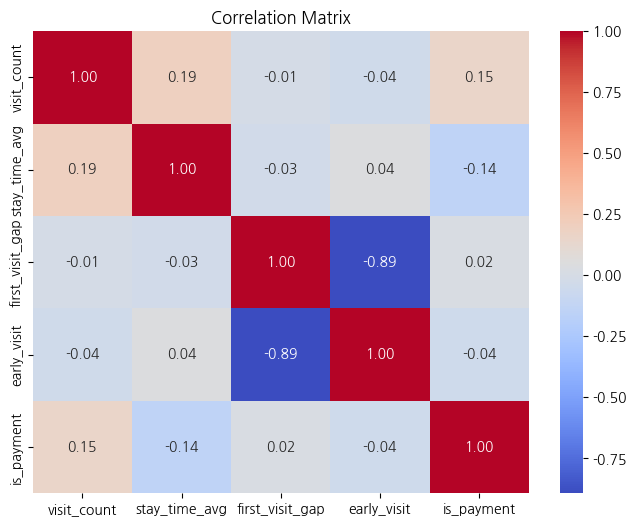

In [36]:
# 선형관계 확인
numeric_cols = ['visit_count', 'stay_time_avg', 'first_visit_gap', 'early_visit', 'is_payment']
# 상관행렬 계산
corr_matrix = features[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

- 종속 변수(is_payment)와 피처들간의 선형관계가 거의 없음이 확인됨
- Logistic Regression으로는 유의미한 패턴 포착 어려움
- 비선형 관계를 기반으로 한 모델 사용
    - DecisionTree, Baggin, RandomForest

## 학습/테스트 데이터 분리

In [37]:
import numpy as np
from sklearn.model_selection import train_test_split

In [38]:
# X: 독립변수 (입력값)
X = features.drop(columns=['user_uuid', 'is_payment'])

# y: 종속변수 (예측 대상)
y = features['is_payment']

# train-test 분리
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=89)

## 결정트리 (Decision Tree)

### 모델 학습

In [39]:
from sklearn.tree import DecisionTreeClassifier

In [40]:
# 단일 결정트리
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### 모델 평가

- 정확도 / 분류 리포트 / ROC AUC

In [41]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import roc_auc_score

dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

In [42]:
print("🌳 Decision Tree")
print("Accuracy:", round(accuracy_score(y_test, dt_pred), 2))
print("ROC AUC:", round(roc_auc_score(y_test, dt_proba), 2))
print(classification_report(y_test, dt_pred))

🌳 Decision Tree
Accuracy: 0.76
ROC AUC: 0.76
              precision    recall  f1-score   support

           0       0.79      0.79      0.79      1192
           1       0.72      0.73      0.72       899

    accuracy                           0.76      2091
   macro avg       0.76      0.76      0.76      2091
weighted avg       0.76      0.76      0.76      2091



## 배깅

### 모델 학습

In [43]:
from sklearn.ensemble import BaggingClassifier

In [44]:
# 배깅 (결정트리 기반)
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
bag_model.fit(X_train, y_train)


BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  n_jobs=-1, random_state=42)

### 모델 평가

In [45]:
bag_pred = bag_model.predict(X_test)
bag_proba = bag_model.predict_proba(X_test)[:, 1]

print("🧩 Bagging")
print("Accuracy:", round(accuracy_score(y_test, bag_pred), 2))
print("ROC AUC:", round(roc_auc_score(y_test, bag_proba), 2))
print(classification_report(y_test, bag_pred))

🧩 Bagging
Accuracy: 0.77
ROC AUC: 0.83
              precision    recall  f1-score   support

           0       0.76      0.85      0.81      1192
           1       0.77      0.65      0.71       899

    accuracy                           0.77      2091
   macro avg       0.77      0.75      0.76      2091
weighted avg       0.77      0.77      0.76      2091



## 랜덤 포레스트(RandomForestClassifier)

### 모델 학습

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    oob_score=True,
    random_state=89
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, oob_score=True, random_state=89)

### 모델 평가

In [47]:
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
print("🌲 Random Forest")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 2))
print("ROC AUC:", round(roc_auc_score(y_test, rf_proba), 2))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

🌲 Random Forest
Accuracy: 0.75
ROC AUC: 0.81

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.85      0.80      1192
           1       0.76      0.62      0.68       899

    accuracy                           0.75      2091
   macro avg       0.75      0.74      0.74      2091
weighted avg       0.75      0.75      0.75      2091



# 모델별 평가 종합

|모델|Accuracy|ROC AUC|Recall|Precision|F1-score|
|-------------|-----|-----|-----|------|--------|
|결정 트리|0.76|0.76|0.73|0.72|0.72|
|배깅|0.77|0.83|0.65|0.77|0.71|
|랜덤 포레스트|0.75|0.81|0.62|0.76|0.68|

- 아주 미세한 차이지만 배깅 모델이 성능이 가장 좋기 때문에 배깅 모델의 성능을 향상시키는 방향으로 모델링 진행

#### Feature Importance 시각화

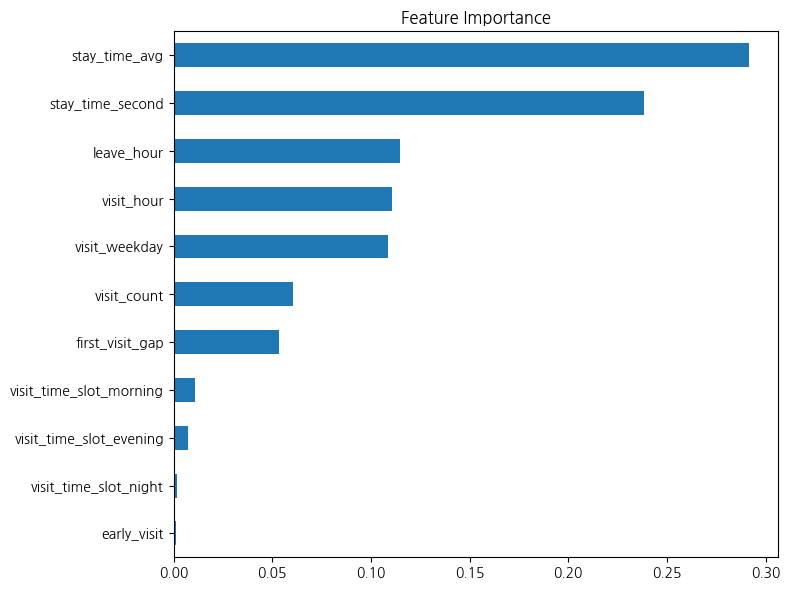

In [48]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

- early_visit은 중요도가 낮지만 3일 내에 방문한 유저들의 전환율을 확인할 수 있는 좋은 지표이기 때문에 제거하지 않고 유지

# 모델 성능 향상

## 파생변수 추가

In [49]:
# 체류시간 구간화
features['stay_time_bin'] = pd.cut(features['stay_time_second'], bins=[0, 1800, 3600, 10000], labels=['short', 'mid', 'long'])

# 평일/주말
features['is_weekend'] = features['visit_weekday'].apply(lambda x: 1 if x in [5, 6] else 0)

In [50]:
# category 해제
features['stay_time_bin'] = features['stay_time_bin'].astype(str)

# map + fillna + int 변환
stay_map = {'short': 0, 'mid': 1, 'long': 2}
features['stay_time_bin'] = (features['stay_time_bin'].map(stay_map).fillna(-1).astype(int))

In [51]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10454 entries, 0 to 10453
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_uuid                10454 non-null  object 
 1   visit_count              10454 non-null  int64  
 2   stay_time_avg            10454 non-null  float64
 3   first_visit_gap          10454 non-null  int64  
 4   early_visit              10454 non-null  int64  
 5   visit_hour               10454 non-null  int32  
 6   leave_hour               10454 non-null  int32  
 7   visit_weekday            10454 non-null  int32  
 8   is_payment               10454 non-null  int64  
 9   stay_time_second         10454 non-null  float64
 10  visit_time_slot_evening  10454 non-null  int64  
 11  visit_time_slot_morning  10454 non-null  int64  
 12  visit_time_slot_night    10454 non-null  int64  
 13  stay_time_bin            10454 non-null  int64  
 14  is_weekend            

In [52]:
# X: 독립변수 (입력값)
X = features.drop(columns=['user_uuid', 'is_payment'])

# y: 종속변수 (예측 대상)
y = features['is_payment']

# train-test 분리
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=89)

### 배깅

In [53]:
bagf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
bagf.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  n_jobs=-1, random_state=42)

In [54]:
bagf_pred = bagf.predict(X_test)
bagf_proba = bagf.predict_proba(X_test)[:, 1]

print("🧩 Bagging with new features")
print("Accuracy:", round(accuracy_score(y_test, bagf_pred), 2))
print("ROC AUC:", round(roc_auc_score(y_test, bagf_proba), 2))
print(classification_report(y_test, bagf_pred))

🧩 Bagging with new features
Accuracy: 0.77
ROC AUC: 0.83
              precision    recall  f1-score   support

           0       0.76      0.85      0.80      1192
           1       0.77      0.65      0.71       899

    accuracy                           0.77      2091
   macro avg       0.77      0.75      0.76      2091
weighted avg       0.77      0.77      0.76      2091



### 랜덤 포레스트

In [55]:
rff = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    oob_score=True,
    random_state=89
)

rff.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, oob_score=True, random_state=89)

In [56]:
rff_pred = rff.predict(X_test)
rff_proba = rff.predict_proba(X_test)[:, 1]
print("🌲 Random Forest with new features")
print("Accuracy:", round(accuracy_score(y_test, rff_pred), 2))
print("ROC AUC:", round(roc_auc_score(y_test, rff_proba), 2))
print("\nClassification Report:\n", classification_report(y_test, rff_pred))

🌲 Random Forest with new features
Accuracy: 0.73
ROC AUC: 0.79

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.84      0.78      1192
           1       0.74      0.58      0.65       899

    accuracy                           0.73      2091
   macro avg       0.73      0.71      0.72      2091
weighted avg       0.73      0.73      0.72      2091



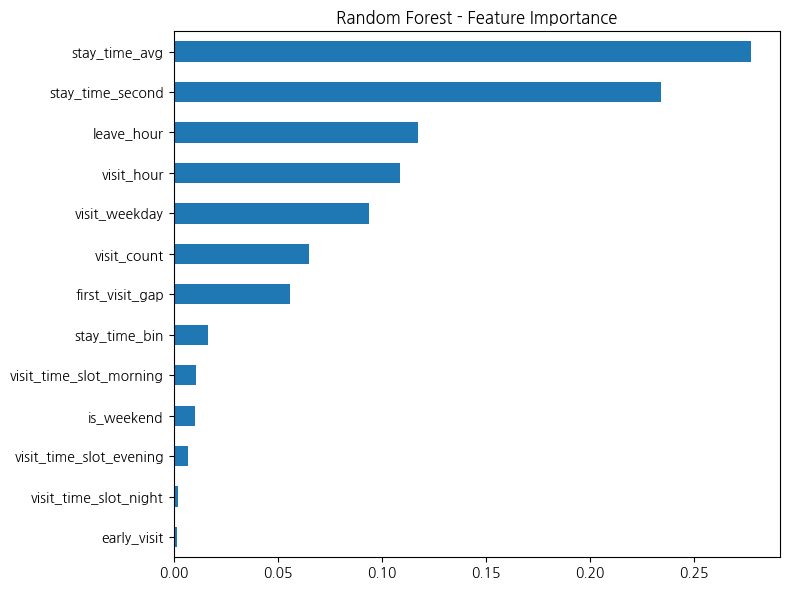

In [57]:
importances = pd.Series(rff.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Random Forest - Feature Importance")
plt.tight_layout()
plt.show()

## stratify 옵션

In [58]:
# X: 독립변수 (입력값)
X = features.drop(columns=['user_uuid', 'is_payment'])

# y: 종속변수 (예측 대상)
y = features['is_payment']

# train-test 분리(stratify 옵션 주기)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=89)

### 배깅

In [59]:
bags = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
bags.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  n_jobs=-1, random_state=42)

In [60]:
bags_pred = bags.predict(X_test)
bags_proba = bags.predict_proba(X_test)[:, 1]

print("🧩 Bagging with stratify")
print("Accuracy:", round(accuracy_score(y_test, bags_pred), 2))
print("ROC AUC:", round(roc_auc_score(y_test, bags_proba), 2))
print(classification_report(y_test, bags_pred))

🧩 Bagging with stratify
Accuracy: 0.76
ROC AUC: 0.82
              precision    recall  f1-score   support

           0       0.77      0.84      0.81      1218
           1       0.75      0.65      0.70       873

    accuracy                           0.76      2091
   macro avg       0.76      0.75      0.75      2091
weighted avg       0.76      0.76      0.76      2091



### 랜덤 포레스트

In [61]:
rfs = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    oob_score=True,
    random_state=89
)

rfs.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, oob_score=True, random_state=89)

In [62]:
rfs_pred = rfs.predict(X_test)
rfs_proba = rfs.predict_proba(X_test)[:, 1]
print("🌲 Random Forest with stratify")
print("Accuracy:", round(accuracy_score(y_test, rfs_pred), 2))
print("ROC AUC:", round(roc_auc_score(y_test, rfs_proba), 2))
print("\nClassification Report:\n", classification_report(y_test, rfs_pred))

🌲 Random Forest with stratify
Accuracy: 0.75
ROC AUC: 0.8

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.86      0.80      1218
           1       0.75      0.60      0.67       873

    accuracy                           0.75      2091
   macro avg       0.75      0.73      0.73      2091
weighted avg       0.75      0.75      0.75      2091



## 가중치 주기

### 배깅

In [63]:
bagwb = BaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight='balanced'),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
bagwb.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced'),
                  n_estimators=100, n_jobs=-1, random_state=42)

In [64]:
bagwb_pred = bagwb.predict(X_test)
bagwb_proba = bagwb.predict_proba(X_test)[:, 1]

print("🧩 Bagging with balanced weight")
print("Accuracy:", round(accuracy_score(y_test, bagwb_pred), 2))
print("ROC AUC:", round(roc_auc_score(y_test, bagwb_proba), 2))
print(classification_report(y_test, bagwb_pred))

🧩 Bagging with balanced weight
Accuracy: 0.77
ROC AUC: 0.83
              precision    recall  f1-score   support

           0       0.77      0.86      0.81      1218
           1       0.76      0.64      0.70       873

    accuracy                           0.77      2091
   macro avg       0.77      0.75      0.75      2091
weighted avg       0.77      0.77      0.76      2091



### 랜덤 포레스트

In [65]:
rfwb = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    oob_score=True,
    class_weight='balanced',
    random_state=89
)

rfwb.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, oob_score=True,
                       random_state=89)

In [66]:
rfwb_pred = rfwb.predict(X_test)
rfwb_proba = rfwb.predict_proba(X_test)[:, 1]
print("🌲 Random Forest with balanced weight")
print("Accuracy:", round(accuracy_score(y_test, rfwb_pred), 2))
print("ROC AUC:", round(roc_auc_score(y_test, rfwb_proba), 2))
print("\nClassification Report:\n", classification_report(y_test, rfwb_pred))

🌲 Random Forest with balanced weight
Accuracy: 0.75
ROC AUC: 0.81

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.85      0.80      1218
           1       0.75      0.61      0.67       873

    accuracy                           0.75      2091
   macro avg       0.75      0.73      0.74      2091
weighted avg       0.75      0.75      0.75      2091



## 그리드 서치

In [67]:
from sklearn.model_selection import GridSearchCV

### 배깅

In [68]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# 배깅 모델 정의 (기본 의사결정나무)
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42,
    n_jobs=-1
)

# 그리드서치용 파라미터 정의
param_grid = {
    'n_estimators': [100, 200],
    'estimator__max_depth': [None, 10, 20],
    'estimator__min_samples_split': [2, 5],
    'estimator__class_weight': [None, 'balanced']
}

# 그리드서치 객체
grid_search = GridSearchCV(
    estimator=bagging,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 학습
grid_search.fit(X_train, y_train)

# 결과 출력
print("Best Params:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("🌟 Bagging with GridSearch Best Params")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 2))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'estimator__class_weight': None, 'estimator__max_depth': None, 'estimator__min_samples_split': 2, 'n_estimators': 100}
🌟 Bagging with GridSearch Best Params
Accuracy: 0.76
ROC AUC: 0.82

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.84      0.81      1218
           1       0.75      0.65      0.70       873

    accuracy                           0.76      2091
   macro avg       0.76      0.75      0.75      2091
weighted avg       0.76      0.76      0.76      2091



### 랜덤 포레스트

In [69]:
# 하이퍼파라미터 그리드 정의
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': [None, 'balanced']
}

# 모델 인스턴스
rfc = RandomForestClassifier(oob_score=True, random_state=89, n_jobs=-1)

# 그리드서치 객체 설정
grid_search = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 학습
grid_search.fit(X_train, y_train)

# 최적 하이퍼파라미터 출력
print("Best Params:", grid_search.best_params_)

# 최적 모델 성능 확인
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("🌲 Random Forest with GridSearch best Params")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 2))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
🌲 Random Forest with GridSearch best Params
Accuracy: 0.76
ROC AUC: 0.81

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.86      0.81      1218
           1       0.76      0.62      0.68       873

    accuracy                           0.76      2091
   macro avg       0.76      0.74      0.74      2091
weighted avg       0.76      0.76      0.75      2091



## 모델 성능 향상 요약

### 배깅

| 모델(배깅)                      | Accuracy | ROC AUC | Recall | Precision | f1-score |
|---------------------------|----------|---------|--------|-----------|----------|
| 기본 Bagging             | 0.77     | 0.83    | 0.65   | 0.77      | 0.71     |
| + 파생변수 추가           | 0.77     | 0.83    | 0.65   | 0.77      | 0.71     |
| + Stratify                | 0.76     | 0.82    | 0.65   | 0.75      | 0.70     |
| + Class Weight            | 0.77     | 0.83    | 0.64   | 0.76      | 0.70     |
| + GridSearch Best         | 0.76     | 0.82    | 0.65   | 0.75      | 0.70     |


### 랜덤 포레스트

| 모델 (랜덤 포레스트)                      | Accuracy | ROC AUC | Recall | Precision | f1-score |
|---------------------------|----------|---------|--------|-----------|----------|
| 기본 RF                  | 0.74     | 0.80    | 0.50   | 0.80      | 0.61     |
| + 파생변수 추가           | 0.73     | 0.79    | 0.58   | 0.74      | 0.65     |
| + Stratify                | 0.75     | 0.80    | 0.60   | 0.75      | 0.67     |
| + Class Weight            | 0.75     | 0.81    | 0.61   | 0.75      | 0.67     |
| + GridSearch Best         | 0.76     | 0.81    | 0.62   | 0.76      | 0.68     |

In [70]:
# 타깃 변수 비율 확인
y.value_counts(normalize=True)

,proportion
is_payment,
0,0.582265
1,0.417735


# 지표 설명

1. Precision (정밀도)
- 모델이 결제라고 예측한 것들 중에 실제로 결제인 비율
- 정답이 결제인 것 중에서 모델이 맞힌 것만 봄
- TP / (TP + FP)
- TP : 실제 결제 + 모델이 결제라고 예측
- FP : 실제 미결제인데 모델이 결제라고 예측

2. Recall (재현율)
- 실제 결제인 사람들 중에 모델이 얼마나 잘 찾아냈는가?
- 진짜 결제한 사람들 중에서 모델이 얼마나 많이 맞혔냐?
- TP / (TP + FN)
- FN : 실제 결제인데 모델이 미결제라고 예측

3. F1-score (조화 평균)
- Precision과 Recall의 균형을 본 지표
- 둘 중 하나라도 낮으면 f1도 낮게 나옴 (민감한 지표)
- 2 * (Precision * Recall) / (Precision + Recall)
- Precision도 중요하고 Recall도 중요한 경우에 유용

4. ROC AUC (곡선 아래 면적)
- 모델이 클래스 0과 1을 얼마나 잘 구분하는지의 종합 평가
- 0.5이면 완전 랜덤 추측 수준
- 1.0이면 완벽한 구분
- 일반적으로 0.70 이상이면 양호, 0.80 이상이면 매우 좋음

# 최종 결론

- 정밀도와 재현율의 균형(f1-score)이 가장 우수한 모델은 BaggingClassifier
- 다양한 피처 실험과 전처리, stratify, class_weight, GridSearch를 거쳤으나
  - Bagging은 성능이 안정적으로 유지되며, f1-score 0.71을 기록
  -RandomForest는 튜닝에도 불구하고 f1-score가 최대 0.68에 머무름
- 클래스 비율이 약 58:42로 심각한 불균형은 아니지만, class_weight 조정은 Bagging에서 유효함
- 중요 피처로는 `stay_time_avg`, `stay_time_second`, `visit_hour`, `leave_hour` 등이 일관되게 높은 중요도를 보임
- 파생변수 추가는 Bagging에선 긍정적 영향을, RandomForest에선 성능 저하 경향을 보여 모델 특성에 따라 다르게 작용

# 최종 선택 모델

```
BaggingClassifier
하이퍼파라미터 기본 설정 (or GridSearch 최적값)  
f1-score: 0.71, 가장 높은 전환 예측 정확도  
ROC AUC: 0.83, 전반적인 분류 성능 우수

따라서 최종적으로는 Bagging이 더 강건하고 예측력이 높은 모델로 판단되며,  
이 모델을 기반으로 인사이트 도출 및 비즈니스 전략 제안을 진행하는 것이 타당함.
```

# 중요 피처 EDA

| 변수명                                | 중요도 해석                            | 비즈니스 인사이트                                       |
| ---------------------------------- | --------------------------------- | --------------------------------------------------- |
| `stay_time_avg`                    | 가장 중요함. 한 사람의 평균 체류 시간이 예측에 크게 기여 | 체류시간이 긴 사람일수록 전환 가능성 높음 → 매장 내 머무는 시간 늘릴 수 있는 전략 필요 |
| `stay_time_second`                 | 두 번째로 중요. 개별 방문의 체류시간도 영향 있음      | 단발 방문이라도 오래 체류하면 전환 가능성↑                            |
| `leave_hour` / `visit_hour`        | 방문 시간대 (입장/퇴장)이 전환과 관련 있음         | 특정 시간대(예: 오전 or 오후)에 방문한 사람을 타겟팅                    |
| `visit_weekday`                    | 요일 정보도 영향 있음                      | 주말 or 특정 요일 방문자 전환율 분석해볼 수 있음                       |
| `visit_count`                      | 방문 횟수는 다소 영향 있음                   | 많이 오는 사람보단, 오랜 시간 머무는 사람에게 집중?                       |
| `first_visit_gap`                  | 신청 후 처음 방문까지의 간격                  | 빠르게 방문한 사람 전환 가능성 분석 가능                             |

## stay_time_avg

In [71]:
features.groupby('stay_time_avg')['is_payment'].mean()

,is_payment
stay_time_avg,
9.0,0.0
11.0,1.0
16.0,0.0
21.0,0.0
51.0,0.5
...,...
51798.0,0.0
52317.0,1.0
52695.5,0.0


In [72]:
features['stay_time_avg_bin'] = pd.qcut(features['stay_time_avg'], q=5, duplicates='drop')
conv_rate = features.groupby('stay_time_avg_bin')['is_payment'].mean()

<ipython-input-72-190130037>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conv_rate = features.groupby('stay_time_avg_bin')['is_payment'].mean()


In [73]:
features.groupby('stay_time_avg_bin').size()

<ipython-input-73-1775982613>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  features.groupby('stay_time_avg_bin').size()


,0
stay_time_avg_bin,
"(8.999, 7593.5]",2092
"(7593.5, 12730.1]",2090
"(12730.1, 17592.667]",2090
"(17592.667, 23574.333]",2092
"(23574.333, 56839.0]",2090


In [74]:
# 구간별 전환율 요약 테이블 만들기
summary = features.groupby('stay_time_avg_bin')['is_payment'].agg(
    total='count',             # 총 사용자 수
    converted='sum',           # 결제한 사용자 수
    conversion_rate='mean'     # 전환율 (평균)
).reset_index()

print(summary)

        stay_time_avg_bin  total  converted  conversion_rate
0         (8.999, 7593.5]   2092       1032         0.493308
1       (7593.5, 12730.1]   2090       1010         0.483254
2    (12730.1, 17592.667]   2090        910         0.435407
3  (17592.667, 23574.333]   2092        777         0.371415
4    (23574.333, 56839.0]   2090        638         0.305263


<ipython-input-74-2031529094>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = features.groupby('stay_time_avg_bin')['is_payment'].agg(


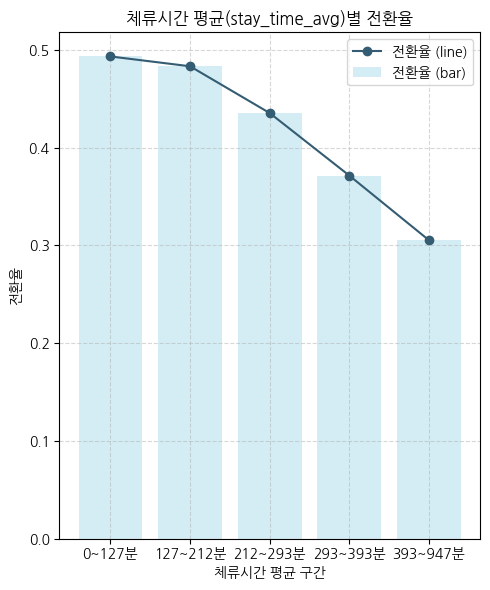

In [75]:
# 구간을 분 단위로 문자열 포맷팅
def format_bin_label(interval):
    left = round(interval.left / 60)    # 초 → 분
    right = round(interval.right / 60)
    return f"{left}~{right}분"

# 새로운 라벨 생성
summary['label'] = summary['stay_time_avg_bin'].apply(format_bin_label)

# 라벨로 시각화
x_labels = summary['label']
y_values = summary['conversion_rate']

plt.figure(figsize=(5, 6))

# 막대 그래프
plt.bar(x_labels, y_values, label='전환율 (bar)', color='#d4edf4')

# 선 그래프
plt.plot(x_labels, y_values, marker='o', label='전환율 (line)', color='#345c72')

plt.title("체류시간 평균(stay_time_avg)별 전환율")
plt.xlabel("체류시간 평균 구간")
plt.ylabel("전환율")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

- "적정 체류시간 구간에서 전환율이 가장 높다"
- 매장 체험을 너무 길게 늘리기보단, 구간에 맞춰 콘텐츠/상담 설계를 최적화할 수 있음

- 체류시간이 길수록 전환율이 무조건 높아질 것이라는 일반적 가정과 달리,
- 중간 체류시간(약 138분 ~ 247분) 구간에서 전환율이 가장 높았고,
- 지나치게 오래 머문 사용자의 전환율은 오히려 낮아지는 경향이 나타났습니다.
- 이는 탐색만 하고 떠난 사용자, 의사결정에 피로를 느낀 사용자 등 다양한 행동 패턴을 반영하는 결과로 해석할 수 있으며,
- 체험 콘텐츠 운영에 있어 적정 체류시간 설계가 중요함을 시사합니다.

## stay_time_second

In [76]:
# 체류 시간과 결제 여부를 병합
merged = visit.merge(payment, on='user_uuid', how='left')
merged['is_payment'] = merged['is_payment'].fillna(0).astype(int)

<ipython-input-77-579139506>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_payment', y='stay_time_second', data=merged, palette='pastel')


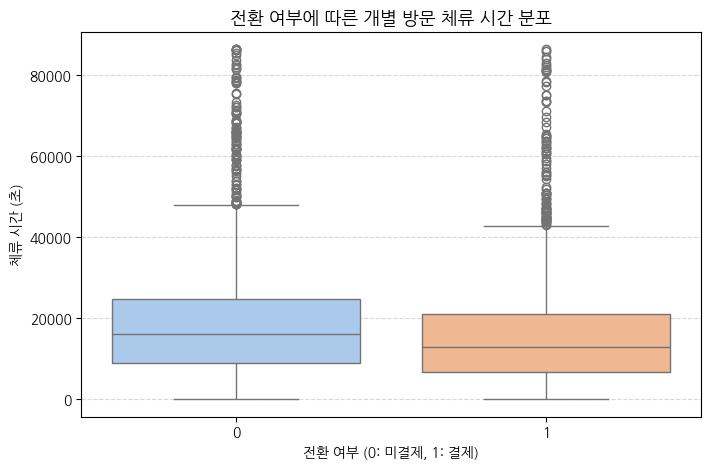

In [77]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_payment', y='stay_time_second', data=merged, palette='pastel')
plt.title("전환 여부에 따른 개별 방문 체류 시간 분포", fontsize=13)
plt.xlabel("전환 여부 (0: 미결제, 1: 결제)")
plt.ylabel("체류 시간 (초)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

- 전체적으로 큰 차이가 보이지 않음
- 이상치 많음 -> 분포 왜곡 가능성 있음

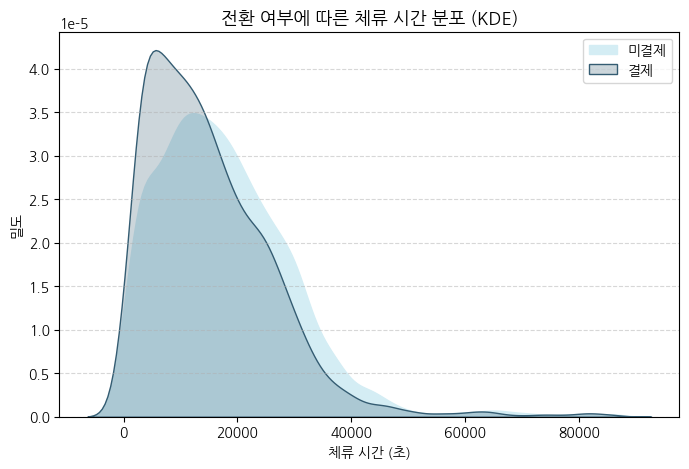

In [78]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=merged[merged['is_payment']==0]['stay_time_second'], label='미결제', fill=True, color='#d4edf4', alpha=1.0)
sns.kdeplot(data=merged[merged['is_payment']==1]['stay_time_second'], label='결제', fill=True, color='#345c72')
plt.title("전환 여부에 따른 체류 시간 분포 (KDE)", fontsize=13)
plt.xlabel("체류 시간 (초)")
plt.ylabel("밀도")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

- 결제자가 미결제자보다 체류시간이 전반적으로 짧은 경향이 있음
- 피크 위치는 비슷하나, 꼬리가 더 두꺼움

<ipython-input-79-1528722560>:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion_by_bin = merged.groupby('stay_time_bin')['is_payment'].mean().reset_index()
<ipython-input-79-1528722560>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='stay_time_bin', y='is_payment', data=conversion_by_bin, palette='Set2')


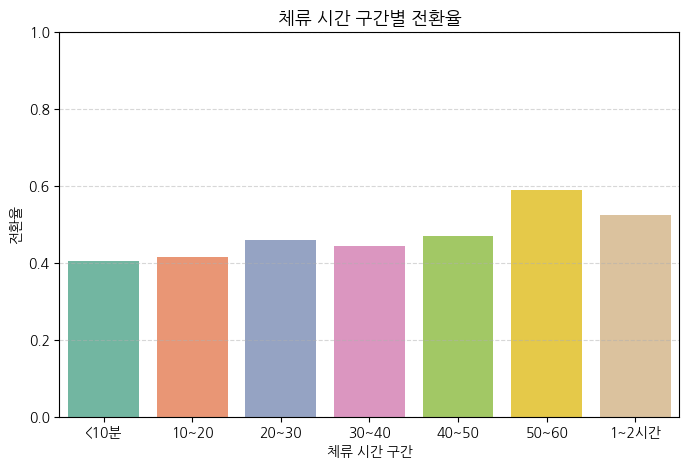

In [79]:
# 구간 나누기
bins = [0, 600, 1200, 1800, 2400, 3000, 3600, 7200]
labels = ['<10분', '10~20', '20~30', '30~40', '40~50', '50~60', '1~2시간']
merged['stay_time_bin'] = pd.cut(merged['stay_time_second'], bins=bins, labels=labels)

# 구간별 전환율 계산
conversion_by_bin = merged.groupby('stay_time_bin')['is_payment'].mean().reset_index()

# 시각화
plt.figure(figsize=(8, 5))
sns.barplot(x='stay_time_bin', y='is_payment', data=conversion_by_bin, palette='Set2')
plt.title("체류 시간 구간별 전환율", fontsize=13)
plt.xlabel("체류 시간 구간")
plt.ylabel("전환율")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

- 체류 시간이 길어질수록 전호한율 증가하는 경향, 하지만 큰 차이는 아님
- 중간 구간에 프로모션 집중해볼 수 있음 (30~60분)

- 개별 방문 기준으로는, 결제자의 체류 시간이 미결제자보다 더 짧은 경향이 관찰됨.
- KDE plot과 boxplot 모두 이를 지지하며, 이는 장시간 체류했다고 해서 반드시 전환되는 것은 아님을 시사함.
- 특정 시간(예: 50~60분)에서 전환율이 높은 현상은 있으나,
- 전반적으로는 체류 시간만으로 결제를 예측하는 데 한계가 존재할 수 있음.

## visit_hour

In [80]:
# 1. 그룹핑 및 필터링
hourly_summary = features.groupby('visit_hour')['is_payment'].agg(['mean', 'count']).reset_index()
hourly_summary.columns = ['visit_hour', 'conversion_rate', 'visit_count']
filtered = hourly_summary[hourly_summary['visit_count'] >= 30].copy()
filtered['visit_hour'] = filtered['visit_hour'].astype(int)
filtered = filtered.sort_values('visit_hour')

# 그래프 정렬용 카테고리 변환
filtered['visit_hour'] = pd.Categorical(
    filtered['visit_hour'], categories=range(24), ordered=True
)

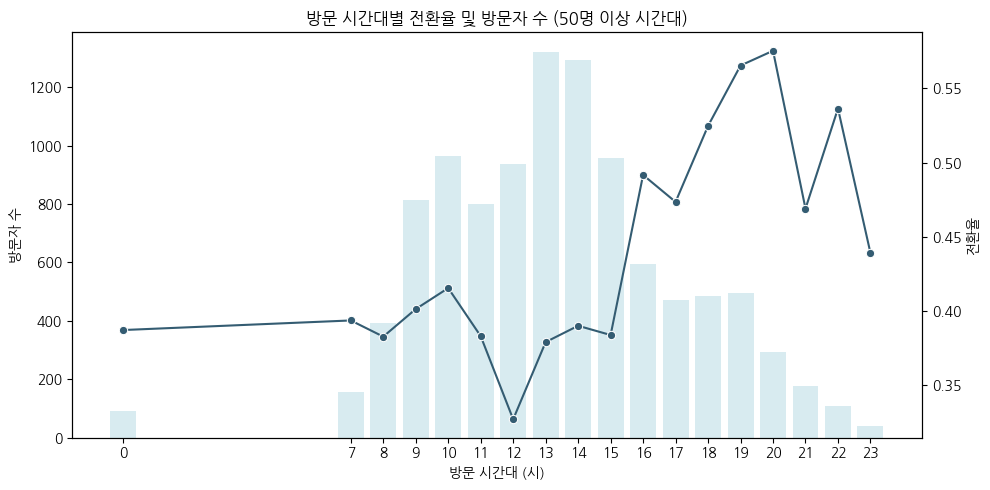

In [81]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# 막대 그래프 (방문자 수)
color_bar = '#d4edf4'
sns.barplot(
    x='visit_hour', y='visit_count', data=filtered,
    ax=ax1, color=color_bar, zorder=1
)
ax1.set_ylabel('방문자 수', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# 이중 y축 선언
ax2 = ax1.twinx()

# 선 그래프 (전환율)
sns.lineplot(
    x='visit_hour', y='conversion_rate',
    data=filtered.sort_values('visit_hour'),
    ax=ax2, color='#345c72', marker='o', zorder=2
)
ax2.set_ylabel('전환율', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# x축 및 제목
ax1.set_xlabel('방문 시간대 (시)')
ax1.set_xticks(filtered['visit_hour'])
ax1.set_title("방문 시간대별 전환율 및 방문자 수 (50명 이상 시간대)")

plt.tight_layout()
plt.show()

- 방문 시간대별 분석 결과, 13시에 방문자가 가장 많으며,
- 9~15시가 전체 방문의 중심 시간대.
- 반면, 20시 이후의 저녁 시간대에는 방문자는 적지만 전환율이 높은 특징
- 이는 저녁 시간대 방문자가 목적 의식이 뚜렷한 체험자일 가능성을 시사함
- 따라서 주간 시간대에는 유입 확대 전략, 야간 시간대에는 전환 최적화 전략을 차별적으로 운영하는 것이 효과적일 수 있음

## leave_hour

In [82]:
# 그룹핑 및 필터링
hourly_summary = features.groupby('leave_hour')['is_payment'].agg(['mean', 'count']).reset_index()
hourly_summary.columns = ['leave_hour', 'conversion_rate', 'visit_count']
filtered = hourly_summary[hourly_summary['visit_count'] >= 50].copy()
filtered['leave_hour'] = filtered['leave_hour'].astype(int)
filtered = filtered.sort_values('leave_hour')

# x축 범주형 순서 고정
filtered['leave_hour'] = pd.Categorical(
    filtered['leave_hour'], categories=range(24), ordered=True
)

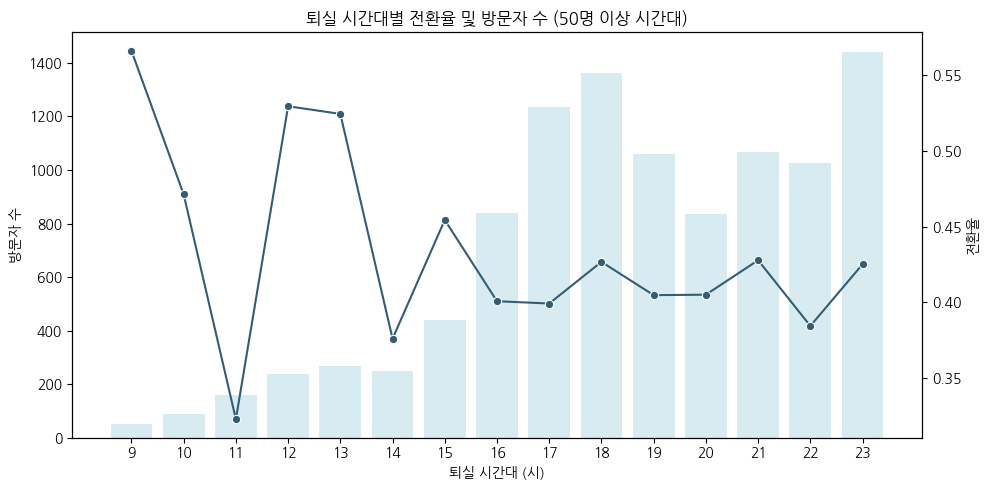

In [83]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# 막대 그래프: 방문자 수
sns.barplot(
    x='leave_hour', y='visit_count', data=filtered,
    ax=ax1, color='#d4edf4', zorder=1
)
ax1.set_ylabel('방문자 수', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# 이중 y축: 전환율 선 그래프
ax2 = ax1.twinx()
sns.lineplot(
    x='leave_hour', y='conversion_rate', data=filtered.sort_values('leave_hour'),
    ax=ax2, color='#345c72', marker='o', zorder=2
)
ax2.set_ylabel('전환율', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# x축 및 제목
ax1.set_xlabel('퇴실 시간대 (시)')
ax1.set_title("퇴실 시간대별 전환율 및 방문자 수 (50명 이상 시간대)")

# 눈금 간소화 (선택)
ax1.set_xticks(filtered['leave_hour'])

plt.tight_layout()
plt.show()


- 퇴실 시간 기준 분석 결과, 18시에 퇴실한 고객의 수가 가장 많음
- 업무 목적으로 사용하는 유저일 가능성 있음
- 오전 시간에는 전환율이 가장 낮거나 가장 높은 것 확인
- 퇴실자가 적어서 데이터 불균형으로 극단값들을 보일 가능성 있음
- 전환 보다는 퇴실자가 가장 많은 18시 전후 집중 응대 및 전환 유도 전략이 효과적일듯

## visit_weekday

In [84]:
# 요약 테이블 만들기
weekday_summary = features.groupby('visit_weekday')['is_payment'].agg(['mean', 'count']).reset_index()
weekday_summary.columns = ['visit_weekday', 'conversion_rate', 'visit_count']

In [85]:
# 0:월, 1:화, ..., 6:일
weekday_map = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
weekday_summary['weekday_label'] = weekday_summary['visit_weekday'].map(weekday_map)

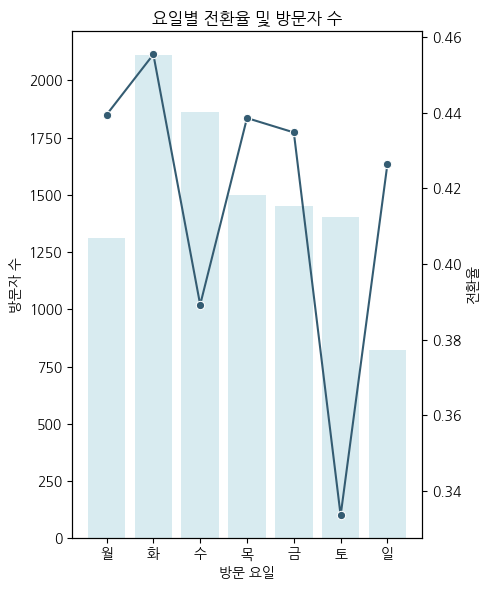

In [86]:
fig, ax1 = plt.subplots(figsize=(5, 6))

# 막대 그래프: 방문자 수
sns.barplot(x='weekday_label', y='visit_count',
            data=weekday_summary, ax=ax1,
            color='#d4edf4', zorder=1)
ax1.set_ylabel('방문자 수', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# 이중 y축
ax2 = ax1.twinx()

# 선 그래프: 전환율
sns.lineplot(x='weekday_label', y='conversion_rate',
             data=weekday_summary, marker='o',
             ax=ax2, color='#345c72', zorder=2)
ax2.set_ylabel('전환율', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# 제목, x축
ax1.set_xlabel('방문 요일')
ax1.set_title('요일별 전환율 및 방문자 수')

plt.tight_layout()
plt.show()

- 화요일이 방문자 수와 전환율 모두 가장 높게 나옴
- 토요일은 방문자는 적지 않음에도 전환율이 가장 낮음
- 일요일은 방문자 수가 가장 적지만 전환율은 상대적으로 높음
- 화요일 집중 운영, 토요일 전환 개선, 일요일 타겟 유입 확대 전략

# 인사이트

1. 시간대 기반 전략
- 18시 퇴실자 수가 가장 많음 -> 6시에 퇴장하는 공유 오피스 사용자? 업무용으로 방문한 경우가 높지 않을까?
    - 18시에 퇴실하는 유저 기반으로 추후 회의실 1시간 무료 이용권 증정
    - 퇴실 후 1시간 이내 자동 메시지 발송
    - ex. "오늘 어떠셨나요? 내일은 미팅룸 1시간 무료 쿠폰 드릴게요"
- 21시 이후 방문자 전환율 높음
    - 예약 사이트나 어플 상단에 야간 체험 가능성 강조
    - ex. "늦게까지도 운영돼요!"
    - 야간 예약자에게 전용 리마인드 메시지
    - ex. "내일도 조용히 일하고 싶다면? 지금 결제하고 자리 확보하세요!"
- 체류 시간이 너무 길면 오히려 전환 낮음

2. 요일 기반 전략
- 화요일: 방문자 수와 전환율 모두 최고 -> 광고/이벤트 집중 요일로 선정
    - ex. 화요일 방문 예약 시, 특별 혜택 제공
- 토용리: 방문자 수는 중상위지만 전환율 최저 -> 토요일 방문자에겐 후속 리마인드 메시지 강화
    - ex. 토요일 방문 감사드려요! 이틀 안에 결제 시 혜택 드려요"

- 18시 퇴실자는 업무형 사용자가 많아 결제 전환 가능성이 높음 -> 이 타이밍에 맞춘 퇴장 직후 리마인드 or 혜택 재공 필요
- 야간 체험자는 목적성 강한 고전환 유저로, 야간 운영 가능성을 노출하고 전용 혜택 제공 전략 유효
- 화요일은 전환 효율 최고 요일로, 마케팅/상담 리소스 집중 타이밍으로 적합
- 토요일은 방문 대비 전환 저조 -> 후속 커뮤니케이션 강화 및 짧고 명확한 체험 가이드 제공 전략 필요